In [1]:
import pandas as pd
import numpy as np
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import PowerTransformer

from funciones import *

In [2]:
# Abrir archivo raw_data
data_folder = "../data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ticker               502 non-null    str    
 1   Sector               499 non-null    str    
 2   MarketCap            500 non-null    float64
 3   Beta                 496 non-null    float64
 4   DividendYield        407 non-null    float64
 5   ForwardPE            500 non-null    float64
 6   trailingPegRatio     428 non-null    float64
 7   PriceToBook          500 non-null    float64
 8   EnterpriseToEbitda   469 non-null    float64
 9   ReturnOnAssets       497 non-null    float64
 10  returnOnEquity       468 non-null    float64
 11  profitMargins        499 non-null    float64
 12  operatingMargins     499 non-null    float64
 13  currentRatio         480 non-null    float64
 14  debtToEquity         452 non-null    float64
 15  revenueGrowth        497 non-null    float64
 16  s

# Variables continuas

In [3]:
# Formatear market cap en billions
df["MarketCap"] = df["MarketCap"] / 10**9

# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
MarketCap,500.0,130.14,420.39,5.83,21.75,40.18,90.68,4587.58
Beta,496.0,0.98,0.46,0.00,0.65,0.99,1.25,3.61
DividendYield,407.0,2.28,1.63,0.02,1.06,1.98,3.08,9.58
ForwardPE,500.0,15.19,79.41,-1643.07,12.05,17.15,23.17,128.60
trailingPegRatio,428.0,3.28,12.89,0.13,1.08,1.72,2.56,216.92
PriceToBook,500.0,5.37,78.71,-1152.98,1.82,3.26,7.17,1250.15
EnterpriseToEbitda,469.0,24.96,228.70,-1966.38,11.22,14.91,20.88,4509.91
ReturnOnAssets,497.0,0.07,0.06,-0.15,0.03,0.05,0.09,0.51
returnOnEquity,468.0,0.55,4.40,-0.86,0.09,0.15,0.29,71.50
profitMargins,499.0,0.14,0.15,-1.45,0.07,0.13,0.21,0.73


In [4]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

MarketCap               7.775304
Beta                    1.031091
DividendYield           1.233758
ForwardPE             -19.002757
trailingPegRatio       13.824465
PriceToBook             1.586400
EnterpriseToEbitda     14.790930
ReturnOnAssets          2.565315
returnOnEquity         14.936749
profitMargins          -2.439503
operatingMargins       -0.863659
currentRatio            4.980718
debtToEquity           13.462610
revenueGrowth           4.600738
shortPercentOfFloat     2.658170
dtype: float64

Cont


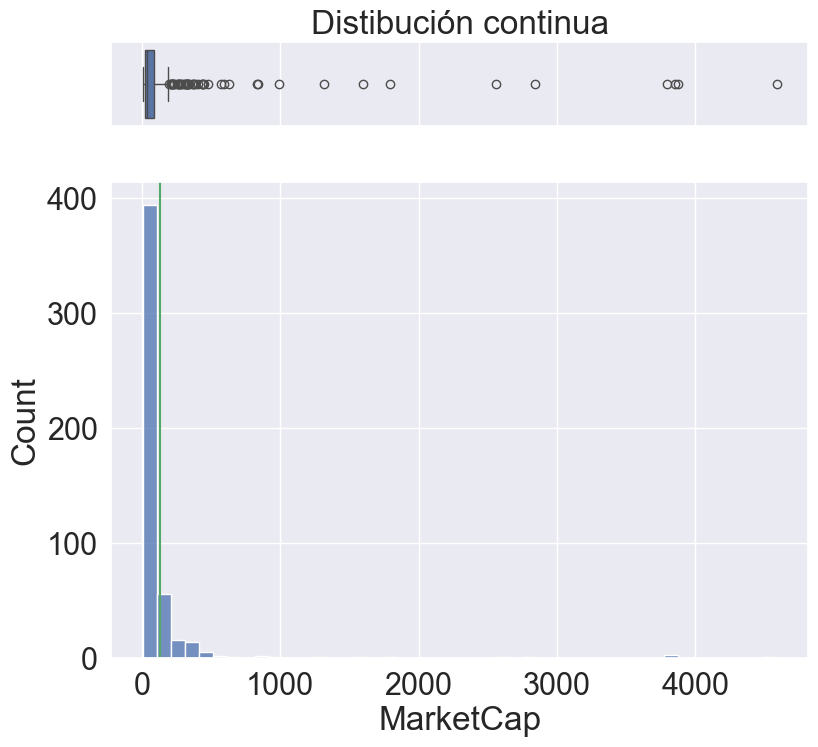

In [5]:
# Graficar
columna_a_graficar = 'MarketCap' # indicar columna para el grafico
plot(df[columna_a_graficar])

Transformaciones yeo-johnson sobre las variables:
* `PriceToBook`
* `returnOnEquity`
* `ForwardPE`

In [6]:
# Transformar
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'ForwardPE']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

Transformaciones logaritmicas sobre las variables:
* `MarketCap`
* `debtToEquity`
* `trailingPegRatio`

In [ ]:
# Transformar
columnas_a_transformar = ['MarketCap', 'debtToEquity', 'trailingPegRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

Beta                           1.031091
DividendYield                  1.233758
EnterpriseToEbitda            14.790930
ReturnOnAssets                 2.565315
profitMargins                 -2.439503
operatingMargins              -0.863659
currentRatio                   4.980718
revenueGrowth                  4.600738
shortPercentOfFloat            2.658170
PriceToBook_Transformed        4.785607
returnOnEquity_Transformed    -1.757148
ForwardPE_Transformed          3.301768
MarketCap_log                  1.020221
debtToEquity_log              -0.209085
trailingPegRatio_log           2.672777
dtype: float64

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [ ]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Beta
DividendYield
EnterpriseToEbitda
ReturnOnAssets
profitMargins
operatingMargins
currentRatio
revenueGrowth
shortPercentOfFloat
PriceToBook_Transformed
returnOnEquity_Transformed
ForwardPE_Transformed
MarketCap_log
debtToEquity_log
trailingPegRatio_log


Beta                          1.028393
DividendYield                 1.212567
EnterpriseToEbitda           -0.107286
ReturnOnAssets                1.308978
profitMargins                 0.019670
operatingMargins             -0.093675
currentRatio                  1.517947
revenueGrowth                 1.073703
shortPercentOfFloat           1.636213
PriceToBook_Transformed       0.314929
returnOnEquity_Transformed    0.541562
ForwardPE_Transformed         1.193872
MarketCap_log                 1.020221
debtToEquity_log             -0.209085
trailingPegRatio_log          1.321491
dtype: float64

In [14]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Beta                          1.028393
DividendYield                 1.212567
EnterpriseToEbitda           -0.107286
ReturnOnAssets                1.308978
profitMargins                 0.019670
operatingMargins             -0.093675
currentRatio                  1.517947
revenueGrowth                 1.073703
shortPercentOfFloat           1.636213
PriceToBook_Transformed       0.314929
returnOnEquity_Transformed    0.541562
ForwardPE_Transformed         1.193872
MarketCap_log                 1.020221
debtToEquity_log             -0.209085
trailingPegRatio_log          1.321491
dtype: float64

Cont


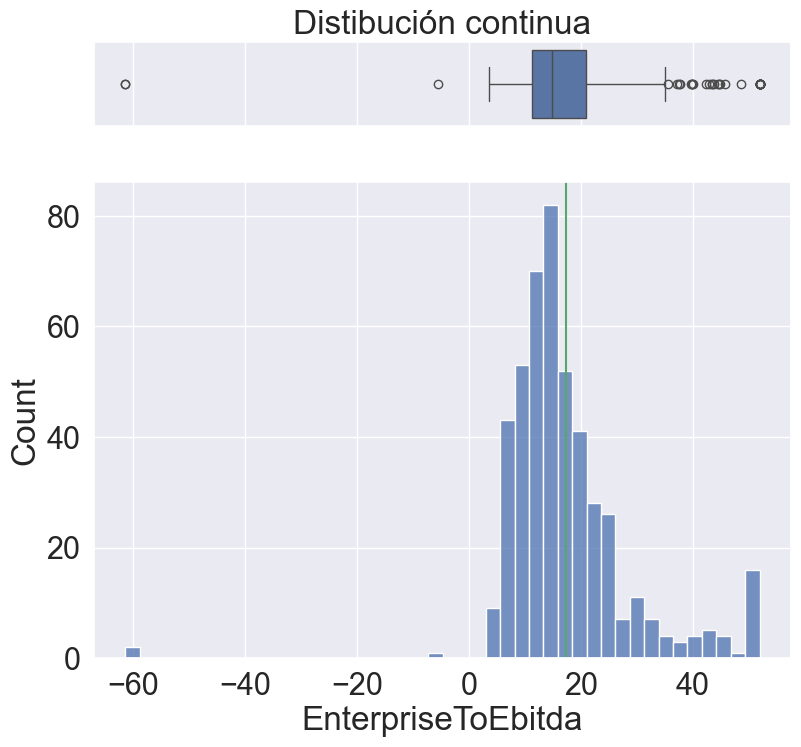

In [15]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [20]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,100.0,2.929874e+00,9.906390,-18.387055,-3.854778,2.454444,8.690918,42.646676
rangePosition,100.0,6.854260e+01,23.671129,5.730000,58.922500,75.465000,85.477500,99.730000
avgReturn,100.0,1.223400e+01,11.027653,-7.630000,6.290000,11.655000,17.642500,54.420000
annualizedVol,100.0,2.834250e+01,8.145430,15.810000,23.312500,26.685000,31.972500,59.870000
sharpeRatio,100.0,2.979000e-01,0.359992,-0.400000,0.080000,0.270000,0.492500,1.330000
Beta,100.0,8.866500e-01,0.474125,0.010000,0.421750,0.911500,1.222500,2.375000
DividendYield,89.0,2.252693e+00,1.493317,0.019700,0.890000,2.220000,3.010000,6.520000
EnterpriseToEbitda,89.0,1.814185e+01,16.669335,-64.613000,11.402000,16.068000,21.444000,94.362000
ReturnOnAssets,100.0,7.826270e-02,0.072357,-0.019990,0.034205,0.062805,0.109047,0.511880
profitMargins,100.0,1.782499e-01,0.128786,-0.234380,0.084505,0.159300,0.283062,0.556030


In [16]:
# Transformar post winsorizacion: EnterpriseToEbitda
df_winsor['EnterpriseToEbitda_Transformed'] = pt.fit_transform(df_winsor[['EnterpriseToEbitda']])
df_winsor.drop('EnterpriseToEbitda', axis=1, inplace=True)

# Variables Categoricas

In [17]:
df_non_numeric = df.select_dtypes(exclude='number')

In [18]:
# Valores unicos
df_non_numeric.nunique()

Ticker    502
Sector     11
dtype: int64

In [19]:
# Convertir Sector a category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')

# Valores unicos
df_non_numeric['Sector'].value_counts()

Sector
Technology                82
Industrials               73
Financial Services        69
Healthcare                60
Consumer Cyclical         53
Consumer Defensive        35
Utilities                 31
Real Estate               30
Communication Services    24
Energy                    22
Basic Materials           20
Name: count, dtype: int64

In [20]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Ticker,Sector
61,BRK.B,NaN
76,BF.B,NaN
200,FISV,NaN


In [21]:
# Asignar manualmente el sector a los 3 tickers con valor nulo
df_non_numeric.loc[df_non_numeric['Ticker'] == 'BRK.B', 'Sector'] = 'Financial Services'
df_non_numeric.loc[df_non_numeric['Ticker'] == 'BF.B', 'Sector'] = 'Consumer Cyclical'
df_non_numeric.loc[df_non_numeric['Ticker'] == 'FISV', 'Sector'] = 'Technology'

In [22]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Ticker,Sector,Beta,DividendYield,ReturnOnAssets,profitMargins,operatingMargins,currentRatio,revenueGrowth,shortPercentOfFloat,PriceToBook_Transformed,returnOnEquity_Transformed,ForwardPE_Transformed,MarketCap_log,debtToEquity_log,trailingPegRatio_log,EnterpriseToEbitda_Transformed
0,MMM,Industrials,1.158,2.08,0.07584,0.13027,0.12408,1.708,0.020,0.0145,0.144620,1.446156,-0.263563,4.391394,5.626318,0.900283,-0.327188
1,AOS,Industrials,1.346,2.12,0.14257,0.14260,0.17951,1.497,0.000,0.0677,-0.012059,0.351421,-0.306829,2.326219,2.482738,0.860693,-0.573328
2,ABT,Healthcare,0.782,2.51,0.06630,0.14718,0.21616,1.576,0.044,0.0153,-0.033031,-0.245422,-0.242827,5.167925,3.324568,0.896578,-0.244118
3,ABBV,Healthcare,0.364,3.33,0.09807,0.06910,0.34108,0.671,0.100,0.0127,-0.262451,2.668696,-0.457618,5.898037,NaN,0.400654,-0.265524
4,ACN,Technology,1.236,3.63,0.11163,0.10606,0.13819,1.336,0.083,0.0332,-0.027963,0.203871,-0.459788,4.769905,3.275974,0.868989,-0.791220


# Missings

In [23]:
df_combined.isnull().sum()

Ticker                             0
Sector                             0
Beta                               6
DividendYield                     95
ReturnOnAssets                     5
profitMargins                      3
operatingMargins                   3
currentRatio                      22
revenueGrowth                      5
shortPercentOfFloat                5
PriceToBook_Transformed            2
returnOnEquity_Transformed        34
ForwardPE_Transformed              2
MarketCap_log                      2
debtToEquity_log                  50
trailingPegRatio_log              74
EnterpriseToEbitda_Transformed    33
dtype: int64

In [24]:
# DividendYield: imputar 0
df_combined['DividendYield'] = df_combined['DividendYield'].fillna(0)

In [25]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [26]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Beta                            502 non-null    float64
 1   DividendYield                   502 non-null    float64
 2   ReturnOnAssets                  502 non-null    float64
 3   profitMargins                   502 non-null    float64
 4   operatingMargins                502 non-null    float64
 5   currentRatio                    502 non-null    float64
 6   revenueGrowth                   502 non-null    float64
 7   shortPercentOfFloat             502 non-null    float64
 8   PriceToBook_Transformed         502 non-null    float64
 9   returnOnEquity_Transformed      502 non-null    float64
 10  ForwardPE_Transformed           502 non-null    float64
 11  MarketCap_log                   502 non-null    float64
 12  debtToEquity_log                502 non-null   

In [ ]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

In [28]:
df_final.select_dtypes(include='number').skew()

Beta                              1.016904
DividendYield                     1.162458
ReturnOnAssets                    1.311454
profitMargins                     0.019674
operatingMargins                 -0.092751
currentRatio                      1.542099
revenueGrowth                     1.077282
shortPercentOfFloat               1.614835
PriceToBook_Transformed           0.312360
returnOnEquity_Transformed        0.541965
ForwardPE_Transformed             1.193458
MarketCap_log                     1.019971
debtToEquity_log                 -0.124454
trailingPegRatio_log              1.266980
EnterpriseToEbitda_Transformed    1.135492
dtype: float64

In [29]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")